# Modular GW Spectrum from Decaying Turbulence

**Goal:** one GW kernel function with switchable models, so different `(spectrum, temporal)` choices can be overlaid on the same axes. Self-contained: no imports from `gw_turbulence.core`, so any bug is local to this notebook.

## Architecture

1. **Spectrum** $\to E(k,t)$, $\Phi(k,t) = E(k,t)/(4\pi k^2)$.
2. **Temporal correlator** $\to$ velocity two-time correlator
   $$F(k; t_1, t_2) = \mathrm{amp}(k; t_1, t_2)\,R(k; t_1, t_2).$$
3. **GW kernel** $\to$ always full finite-$k_{GW}$ triad integral with Gaussian closure:
   $$H(k_{GW}, \omega) = C \int dq\,q^2 \int d\gamma\,\mathcal{K}(\gamma; k_{GW}, q)\, S_{qp}(\omega),$$
   $$S_{qp}(\omega) = \int dt_1\,dt_2\,e^{i\omega(t_1-t_2)} F(q; t_1, t_2)\,F(p; t_1, t_2).$$

$S_{qp}$ is computed by **direct 2D quadrature** on a $(t_1, t_2)$ grid -- slow but unambiguous. No separability shortcuts, no convolution-theorem rewrites. Every shortcut is a place where bugs hide.

## Models

**`spectrum`**
- `loitsiansky`  -- $s=4,\ p=10/7,\ q=2/7$
- `saffman`      -- $s=2,\ p=6/5,\ q=2/5$
- `frozen`       -- $p=q=0$ (stationary baseline)

**`temporal`**

| key | `amp(k; t_1, t_2)` | `R(k; t_1, t_2)` |
| --- | --- | --- |
| `envelope_geom` | $\sqrt{\Phi(k,t_1)\Phi(k,t_2)}$ | $1$ |
| `midpoint_bk`   | $\Phi(k,T)$ with $T=(t_1+t_2)/2$ | $(1+|\tau|/\tau_1(k,T))^{-2/3}$ |
| `stationary_bk` | $\Phi(k,0)$ (frozen) | $(1+|\tau|/\tau_1(k,0))^{-2/3}$ |
| `kraichnan`     | $\Phi(k,T)$ | $\exp(-\eta_k^2(T)\tau^2/2)$ |
| `white`         | $\Phi(k,T)$ | narrow Gaussian (proxy for $\delta(\tau)$) |
| `dni_legacy`    | -- | -- (special: reproduces the existing notebook's shortcut, $S = \mathcal{F}_t[\Phi_q\Phi_p](\omega)$, for comparison) |

$\tau_1(k,T) = 1/[\varepsilon(T)^{1/3} k^{2/3}]$ with $\varepsilon(T) = -\tfrac{1}{2}\,d\langle u^2\rangle/dt$ at the midpoint $T$.

## Comparison plots

$k_{GW}\in\{0,\,0.1,\,0.2\}$ (in units of $1/L_0$, same units as $q$), plotted as separate curves vs $\omega$, for each `(spectrum, temporal)`. The aeroacoustic limit is just the $k_{GW}=0$ curve.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 100, 'font.size': 13, 'lines.linewidth': 2.0})
np.set_printoptions(linewidth=120)

## 1. Parameters and registries

In [ ]:
DEFAULT_PARS = {
    'M':       0.3,    # Mach, u_0/c_s with c_s=1
    'k0':      1.0,    # 1/L_0 -- outer-scale wavenumber
    'tau_st':  1.0,    # decay onset
    'kappa_d': 1e3,    # dissipation cutoff in units of k_p
    't_max':   30.0,
    'n_t':     96,     # 2D quadrature is O(n_t^2) -- keep modest
    'q_min':   1e-2,
    'q_max':   1e2,
    'n_q':     32,
    'n_gamma': 16,
}

INVARIANTS = {
    'loitsiansky': dict(p=10/7, q=2/7, s=4),
    'saffman':     dict(p=6/5,  q=2/5, s=2),
    'frozen':      dict(p=0.0,  q=0.0, s=4),
}

def make_pars(spectrum='loitsiansky', **override):
    p = dict(DEFAULT_PARS)
    p.update(INVARIANTS[spectrum])
    p['spectrum'] = spectrum
    p.update(override)
    p['u0'] = p['M']
    p['l0'] = 1.0 / p['k0']
    return p

## 2. Spectrum models -- $E(k,t)$

$$E(k,t) = u^2(t)\,L(t)\,\phi\!\bigl(kL(t)\bigr),\qquad \phi(\kappa) = \begin{cases}\kappa^s & \kappa<1 \\ \kappa^{-5/3} & 1\le\kappa\le\kappa_d \\ 0 & \kappa>\kappa_d\end{cases}$$

In [ ]:
def phi_shape(kappa, s=4, kappa_d=1e3):
    k = np.asarray(kappa, dtype=float)
    out = np.zeros_like(k)
    ir    = k < 1.0
    inert = (k >= 1.0) & (k <= kappa_d)
    out[ir]    = k[ir]**s
    out[inert] = k[inert]**(-5/3)
    return out

def u_t(t, **pars):
    return pars['u0'] * (1.0 + np.asarray(t, float)/pars['tau_st'])**(-pars['p']/2)

def L_t(t, **pars):
    return pars['l0'] * (1.0 + np.asarray(t, float)/pars['tau_st'])**(pars['q']/2)

def E_kt(k, t, **pars):
    L = L_t(t, **pars); u = u_t(t, **pars)
    return u**2 * L * phi_shape(np.asarray(k)*L, s=pars['s'], kappa_d=pars['kappa_d'])

def Phi_kt(k, t, **pars):
    return E_kt(k, t, **pars) / (4*np.pi*np.asarray(k, float)**2)

### 2 - sanity: $E(k,0)$ for each spectrum

IR slope $k^s$, inertial $k^{-5/3}$, hard cutoff at $\kappa_d/L_0$. Saffman has $k^2$ rise, Loitsiansky has $k^4$.

AttributeError: 'numpy.ndarray' object has no attribute 'loglog'

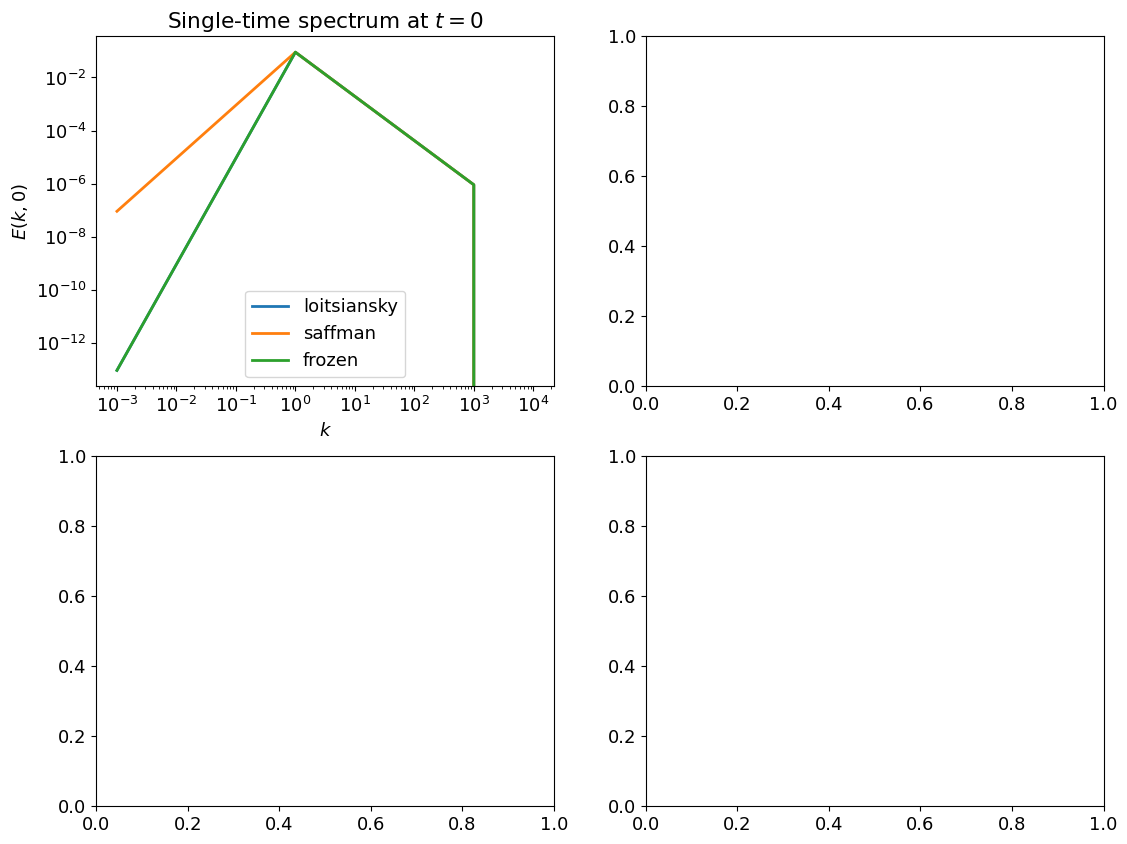

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(13, 10))
ks = np.geomspace(1e-3, 1e4, 400)
TIMES = [0, 1, 5, 25, 100]
CASE = ['loitsiansky', 'saffman', 'frozen']
for spec in CASE :
    axi = ax[0][0]
    pars = make_pars(spec)
    axi.loglog(ks, E_kt(ks, 0.0, **pars), label=spec)
axi.set_xlabel('$k$'); axi.set_ylabel('$E(k, 0)$')
axi.set_title('Single-time spectrum at $t=0$')
axi.legend(); #ax[0].grid(True, which='both', alpha=0.3)

pars = make_pars('loitsiansky')
for t in TIMES :
    ax[1].loglog(ks, E_kt(ks, t, **pars), label=f'$t={t}$')
ax[1].set_xlabel('$k$'); ax[1].set_ylabel('$E(k, t)$')
ax[1].set_title('Loitsiansky time evolution (peak drifts left, amplitude falls)')
ax[1].legend(); #ax[1].grid(True, which='both', alpha=0.3)
plt.tight_layout()

## 3. Temporal correlator -- $F(k; t_1, t_2)$

$$F(k; t_1, t_2) = \mathrm{amp}(k; t_1, t_2) \cdot R(k; t_1, t_2).$$

Different models populate this product differently (see the table at the top).

In [ ]:
def eps_t(T, **pars):
    p = pars['p']
    if p == 0.0:
        # Frozen: no decay, but we still need a positive eps for tau_1 to be finite.
        # Use tau_st as a single eddy-turnover scale: eps_0 = u_0^2 / (2 tau_st).
        return 0.5 * pars['u0']**2 / pars['tau_st'] * np.ones_like(np.asarray(T, float))
    return p * pars['u0']**2 / (2*pars['tau_st']) * (1.0 + np.asarray(T, float)/pars['tau_st'])**(-p-1)

def tau1(k, T, **pars):
    e = eps_t(T, **pars)
    return 1.0 / (e**(1/3) * np.asarray(k, float)**(2/3) + 1e-30)

# --- amplitudes ---
def amp_geom(k, t1, t2, **pars):
    return np.sqrt(Phi_kt(k, t1, **pars) * Phi_kt(k, t2, **pars))

def amp_mid(k, t1, t2, **pars):
    return Phi_kt(k, 0.5*(np.asarray(t1, float)+np.asarray(t2, float)), **pars)

def amp_frozen(k, t1, t2, **pars):
    out = Phi_kt(k, 0.0, **pars)
    return out * np.ones_like(np.asarray(t1, float))

# --- decorrelations ---
def R_one(k, t1, t2, **pars):
    return np.ones_like(np.asarray(t1, float))

def R_bk_T(k, t1, t2, **pars):
    T = 0.5*(np.asarray(t1, float)+np.asarray(t2, float))
    tau = np.abs(np.asarray(t1, float)-np.asarray(t2, float))
    return (1.0 + tau/tau1(k, T, **pars))**(-2/3)

def R_bk_frozen(k, t1, t2, **pars):
    tau = np.abs(np.asarray(t1, float)-np.asarray(t2, float))
    return (1.0 + tau/tau1(k, 0.0, **pars))**(-2/3)

def R_kraichnan(k, t1, t2, **pars):
    T = 0.5*(np.asarray(t1, float)+np.asarray(t2, float))
    tau = np.asarray(t1, float)-np.asarray(t2, float)
    eta = 1.0/tau1(k, T, **pars)
    return np.exp(-(eta*tau)**2 / 2)

def R_white(k, t1, t2, **pars):
    tau = np.asarray(t1, float)-np.asarray(t2, float)
    sigma = pars.get('white_sigma', 2.0*pars['t_max']/pars['n_t'])
    return np.exp(-(tau/sigma)**2/2) / (sigma*np.sqrt(2*np.pi))

TEMPORAL_REGISTRY = {
    'envelope_geom':  (amp_geom,   R_one),
    'midpoint_bk':    (amp_mid,    R_bk_T),
    'stationary_bk':  (amp_frozen, R_bk_frozen),
    'kraichnan':      (amp_mid,    R_kraichnan),
    'white':          (amp_mid,    R_white),
    'dni_legacy':     None,        # special-cased below
}

def F_two_time(k, t1, t2, *, temporal, **pars):
    """F(k; t1, t2) for non-legacy temporal models."""
    amp, R = TEMPORAL_REGISTRY[temporal]
    return amp(k, t1, t2, **pars) * R(k, t1, t2, **pars)

### 3 - sanity: decorrelation profiles $R(\tau; k=1)$

Power-law (BK) vs Gaussian (Kraichnan) vs flat (envelope) -- visually distinct.

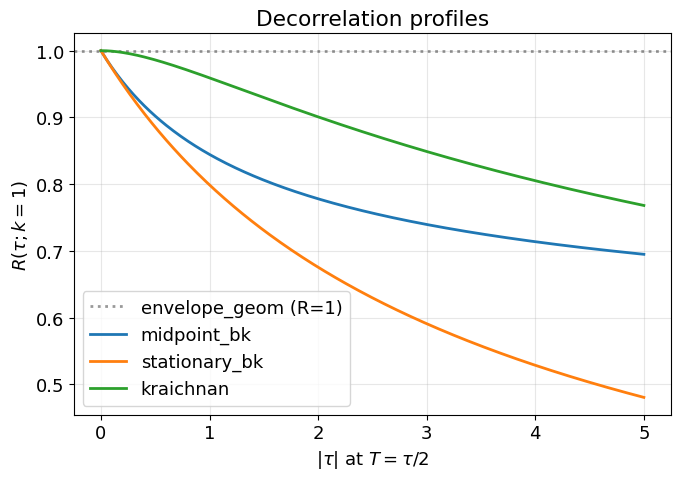

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
pars = make_pars('loitsiansky')
taus = np.linspace(0, 5, 300)
k_probe = 1.0
ax.axhline(1.0, color='k', ls=':', alpha=0.4, label='envelope_geom (R=1)')
for name in ['midpoint_bk', 'stationary_bk', 'kraichnan']:
    _, R = TEMPORAL_REGISTRY[name]
    Rs = R(k_probe, taus, np.zeros_like(taus), **pars)
    ax.plot(taus, Rs, label=name)
ax.set_xlabel(r'$|\tau|$ at $T=\tau/2$'); ax.set_ylabel(r'$R(\tau;k=1)$')
ax.set_title('Decorrelation profiles')
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout()

## 4. Unified GW kernel $H_{gw}(\omega, k_{GW};\,\mathrm{spectrum},\,\mathrm{temporal})$

$$H = \frac{7}{48\pi^6}\cdot\frac{15}{76}\int dq\,q^2 \int d\gamma\,\mathcal{K}(\gamma; k_{GW}, q)\,S_{qp}(\omega).$$

$S_{qp}(\omega) = \int dt_1\,dt_2\,e^{i\omega(t_1-t_2)} F(q;t_1,t_2)\,F(p;t_1,t_2)$ -- direct 2D quadrature, no shortcuts.

The legacy DNI form $S = \mathcal{F}_t[\Phi_q(t)\,\Phi_p(t)](\omega)$ is a special case, kept here for direct comparison.

In [ ]:
def angular_K(gamma, k_gw, q, p_mag):
    if p_mag < 1e-30:
        return 0.0
    if k_gw > 0:
        beta = (k_gw - q*gamma) / p_mag
        c    = (k_gw*gamma - q) / p_mag
    else:
        beta = -gamma; c = -1.0
    return 2 + gamma**2 + beta**2 + (gamma*beta)**2 - c**2 + 2*gamma*beta*c

def S_qp_array(omegas, q_mag, p_mag, ts, *, temporal, **pars):
    """S_qp(omega) = ∫dt1 dt2 cos(ω(t1-t2)) F(q;t1,t2) F(p;t1,t2) for a vector of omegas.
    Real-valued because F(t1,t2)=F(t2,t1) makes the integrand symmetric in t1<->t2."""
    omegas = np.atleast_1d(np.asarray(omegas, float))
    if temporal == 'dni_legacy':
        # Legacy shortcut: treat Phi(k,t) as if it were a stationary R(τ,k) and
        # use S = Re ∫dt e^{iωt} Phi_q(t) Phi_p(t). Kept for direct comparison
        # against the existing notebook's result.
        Phi_q = Phi_kt(q_mag, ts, **pars)
        Phi_p = Phi_kt(p_mag, ts, **pars)
        product = Phi_q * Phi_p
        out = np.empty_like(omegas)
        for i, om in enumerate(omegas):
            out[i] = np.real(np.trapz(product * np.exp(1j*om*ts), ts))
        return out
    T1, T2 = np.meshgrid(ts, ts, indexing='ij')
    F2 = F_two_time(q_mag, T1, T2, temporal=temporal, **pars) * \
         F_two_time(p_mag, T1, T2, temporal=temporal, **pars)
    DT = T1 - T2
    out = np.empty_like(omegas)
    for i, om in enumerate(omegas):
        out[i] = np.trapz(np.trapz(F2 * np.cos(om*DT), ts, axis=1), ts)
    return out

def H_gw(omegas, k_gw=0.0, *,
         spectrum='loitsiansky', temporal='envelope_geom', **override):
    """H(k_gw, omega) via full finite-k triad integral with chosen models.
    omegas may be scalar or array; returns a 1-D array."""
    pars   = make_pars(spectrum, **override)
    omegas = np.atleast_1d(np.asarray(omegas, float))
    ts     = np.linspace(0, pars['t_max'], pars['n_t'])
    qs     = np.geomspace(pars['q_min'], pars['q_max'], pars['n_q'])
    gammas = np.linspace(-1.0, 1.0, pars['n_gamma'])

    integrand_q = np.zeros((len(qs), len(omegas)))
    for iq, q in enumerate(qs):
        gamma_contrib = np.zeros((len(gammas), len(omegas)))
        for ig, g in enumerate(gammas):
            p_mag = float(np.sqrt(max(k_gw**2 + q**2 - 2*k_gw*q*g, 0.0)))
            if p_mag < 1e-30:
                continue
            K = angular_K(g, k_gw, q, p_mag)
            S = S_qp_array(omegas, q, p_mag, ts, temporal=temporal, **pars)
            gamma_contrib[ig, :] = K * S
        integrand_q[iq, :] = q**2 * np.trapz(gamma_contrib, gammas, axis=0)
    return (7.0/(48*np.pi**6)) * (15.0/76.0) * np.trapz(integrand_q, qs, axis=0)

## 5. Sanity check 1: $H(0, \omega)$ for each `temporal` at fixed `spectrum=loitsiansky`

Single curve per model -- look at gross differences (peak position, slope, tail shape). The `dni_legacy` curve is the existing notebook's answer; the others come from the explicit 2D integral.

/tmp/ipykernel_37897/4058361203.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[i] = np.trapz(np.trapz(F2 * np.cos(om*DT), ts, axis=1), ts)
/tmp/ipykernel_37897/4058361203.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrand_q[iq, :] = q**2 * np.trapz(gamma_contrib, gammas, axis=0)
/tmp/ipykernel_37897/4058361203.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return (7.0/(48*np.pi**6)) * (15.0/76.0) * np.trapz(integrand_q, qs, axis=0)
/tmp/ipykernel_37897/4058361203.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[i] = np.real(np.trapz(product * np.exp(1j*om*ts), ts))


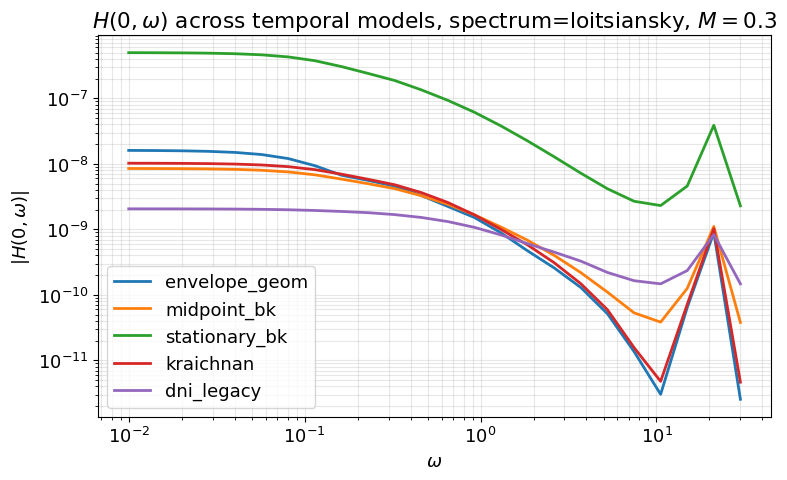

In [ ]:
omegas = np.geomspace(1e-2, 30.0, 24)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for temporal in ['envelope_geom', 'midpoint_bk', 'stationary_bk', 'kraichnan', 'dni_legacy']:
    H = H_gw(omegas, k_gw=0.0, spectrum='loitsiansky', temporal=temporal)
    ax.loglog(omegas, np.abs(H), label=temporal)
ax.set_xlabel(r'$\omega$'); ax.set_ylabel(r'$|H(0,\omega)|$')
ax.set_title(r'$H(0,\omega)$ across temporal models, spectrum=loitsiansky, $M=0.3$')
ax.legend(); ax.grid(True, which='both', alpha=0.3); plt.tight_layout()

## 6. Sanity check 2: $H(k_{GW}, \omega)$ for $k_{GW}\in\{0, 0.1, 0.2\}$

One curve per $k_{GW}$ at each model. Expectation for $k_{GW}\ll k_p$: aeroacoustic regime, curves should overlap. Once $k_{GW}\gtrsim k_p$ the triad constraint should bite and the amplitude drops.

/tmp/ipykernel_37897/4058361203.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[i] = np.trapz(np.trapz(F2 * np.cos(om*DT), ts, axis=1), ts)
/tmp/ipykernel_37897/4058361203.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrand_q[iq, :] = q**2 * np.trapz(gamma_contrib, gammas, axis=0)
/tmp/ipykernel_37897/4058361203.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return (7.0/(48*np.pi**6)) * (15.0/76.0) * np.trapz(integrand_q, qs, axis=0)
/tmp/ipykernel_37897/4058361203.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[i] = np.real(np.trapz(product * np.exp(1j*om*ts), ts))


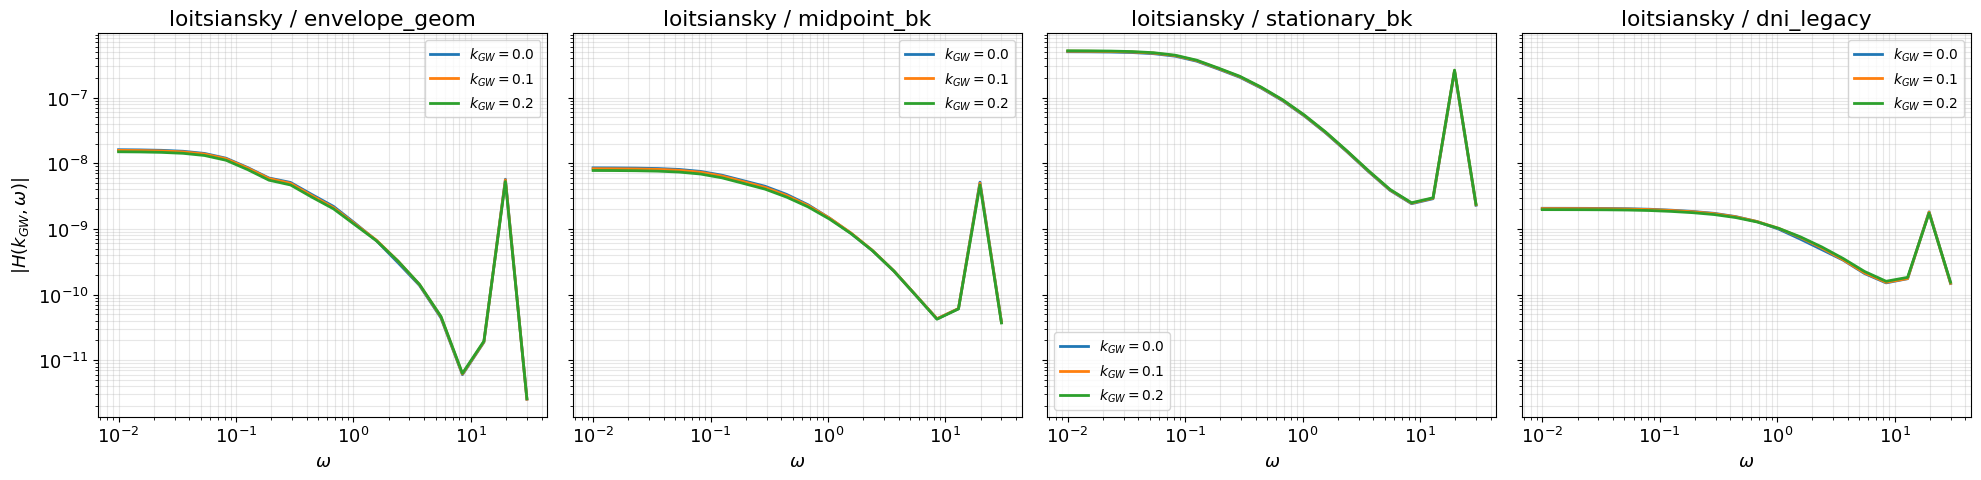

In [ ]:
k_gw_list = [0.0, 0.1, 0.2]
models = [('loitsiansky', 'envelope_geom'),
          ('loitsiansky', 'midpoint_bk'),
          ('loitsiansky', 'stationary_bk'),
          ('loitsiansky', 'dni_legacy')]

fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 5), sharey=True)
omegas = np.geomspace(1e-2, 30.0, 20)
for ax, (spec, temp) in zip(axes, models):
    for k_gw in k_gw_list:
        H = H_gw(omegas, k_gw=k_gw, spectrum=spec, temporal=temp)
        ax.loglog(omegas, np.abs(H), label=f'$k_{{GW}}={k_gw}$')
    ax.set_xlabel(r'$\omega$')
    ax.set_title(f'{spec} / {temp}')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend(fontsize=10)
axes[0].set_ylabel(r'$|H(k_{GW}, \omega)|$')
plt.tight_layout()

## 7. Comparison helper -- arbitrary list of (spectrum, temporal, k_gw)

/tmp/ipykernel_37897/4058361203.py:32: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[i] = np.trapz(np.trapz(F2 * np.cos(om*DT), ts, axis=1), ts)
/tmp/ipykernel_37897/4058361203.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integrand_q[iq, :] = q**2 * np.trapz(gamma_contrib, gammas, axis=0)
/tmp/ipykernel_37897/4058361203.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return (7.0/(48*np.pi**6)) * (15.0/76.0) * np.trapz(integrand_q, qs, axis=0)
/tmp/ipykernel_37897/4058361203.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  out[i] = np.real(np.trapz(product * np.exp(1j*om*ts), ts))


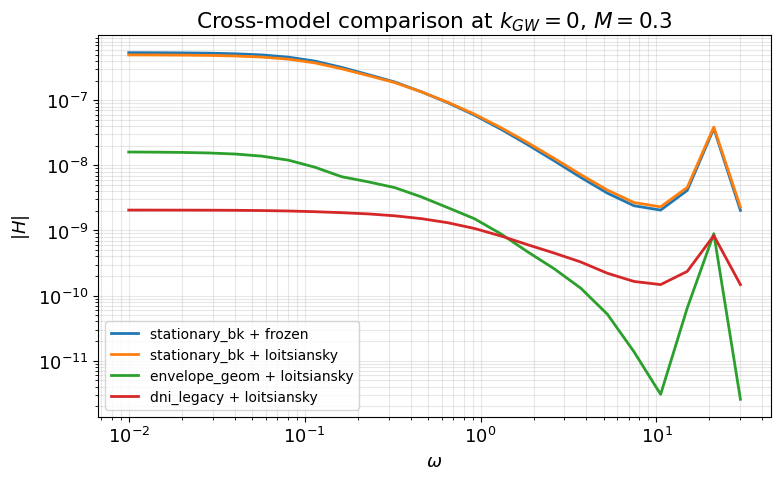

In [ ]:
def compare(configs, omegas=None, ax=None, **override):
    """Overlay |H(k_gw, omega)| for a list of dicts {spectrum, temporal, k_gw, label}."""
    if omegas is None:
        omegas = np.geomspace(1e-2, 30.0, 24)
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    for cfg in configs:
        spec = cfg.get('spectrum', 'loitsiansky')
        temp = cfg.get('temporal', 'envelope_geom')
        kgw  = cfg.get('k_gw', 0.0)
        label = cfg.get('label', f'{spec}/{temp} k={kgw}')
        H = H_gw(omegas, k_gw=kgw, spectrum=spec, temporal=temp, **override)
        ax.loglog(omegas, np.abs(H), label=label,
                  ls=cfg.get('ls', '-'), color=cfg.get('color'))
    ax.set_xlabel(r'$\omega$'); ax.set_ylabel(r'$|H|$')
    ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=10)
    return ax

# example: stationary baselines vs decaying envelope, all at k_gw=0
configs = [
    {'spectrum': 'frozen',      'temporal': 'stationary_bk', 'label': 'stationary_bk + frozen'},
    {'spectrum': 'loitsiansky', 'temporal': 'stationary_bk', 'label': 'stationary_bk + loitsiansky'},
    {'spectrum': 'loitsiansky', 'temporal': 'envelope_geom', 'label': 'envelope_geom + loitsiansky'},
    {'spectrum': 'loitsiansky', 'temporal': 'dni_legacy',    'label': 'dni_legacy + loitsiansky'},
]
compare(configs)
plt.title(r'Cross-model comparison at $k_{GW}=0$, $M=0.3$')
plt.tight_layout()

---

## Scratch

Use this area to drop in new `(spectrum, temporal)` candidates, scan parameters, or run the comparison helper with custom configs. Keep grid sizes small (default `n_t=96`, `n_q=32`) until you're sure of the result; then bump them up.

In [ ]:
# scratch